In [9]:
# Instalação (caso falte algo, mas no Colab já vem tudo)
!pip install nltk -q

# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Configuração de estilo dos gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
# URL pública do dataset SMS Spam (formato TSV - Tab Separated Values)
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'

# Carregar o CSV (sem cabeçalho, definindo nomes das colunas)
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

# Ver as primeiras linhas
print("Primeiras 5 mensagens:")
print(df.head())

# Verificar balanceamento das classes
print("\nDistribuição das classes:")
print(df['label'].value_counts())

# Mapear 'ham' -> 0 (normal) e 'spam' -> 1 (spam)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print(f"\nTotal de registros: {len(df)}")

Primeiras 5 mensagens:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Distribuição das classes:
label
ham     4825
spam     747
Name: count, dtype: int64

Total de registros: 5572


In [11]:
# Configurar stopwords (palavras irrelevantes em inglês, ex: 'the', 'is')
stop_words = set(stopwords.words('english'))

def limpar_texto(texto):
    """
    Função que limpa o texto:
    1. Transforma em minúsculo
    2. Remove caracteres especiais e pontuação (deixa só letras)
    3. Remove stopwords (palavras muito comuns que não ajudam na classificação)
    """
    # 1. Minúsculo
    texto = texto.lower()
    # 2. Remove tudo que não é letra (espaços ficam)
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)
    # 3. Remove stopwords
    texto = ' '.join([palavra for palavra in texto.split() if palavra not in stop_words])
    return texto

# Aplicar a limpeza em todas as mensagens (cria uma nova coluna)
print("Aplicando limpeza nos textos...")
df['mensagem_limpa'] = df['message'].apply(limpar_texto)

# Exemplo de comparação
print("\n--- Exemplo de limpeza ---")
print(f"Original: {df['message'].iloc[0]}")
print(f"Limpa:    {df['mensagem_limpa'].iloc[0]}")

Aplicando limpeza nos textos...

--- Exemplo de limpeza ---
Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Limpa:    go jurong point crazy available bugis n great world la e buffet cine got amore wat


In [12]:
# 1. Separar variáveis (X = texto, y = rótulo)
X = df['mensagem_limpa']
y = df['label_num']  # 0 ou 1

# 2. Dividir em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do treino: {len(X_train)} mensagens")
print(f"Tamanho do teste:  {len(X_test)} mensagens")

# 3. Criar o Vetorizador TF-IDF
#    max_features=5000 -> pega as 5000 palavras mais importantes
vectorizer = TfidfVectorizer(max_features=5000)

# 4. Ajustar o vetorizador nos dados de TREINO e transformar ambos
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"\nShape da matriz TF-IDF de treino: {X_train_tfidf.shape}")
print(f"Shape da matriz TF-IDF de teste:  {X_test_tfidf.shape}")

Tamanho do treino: 4457 mensagens
Tamanho do teste:  1115 mensagens

Shape da matriz TF-IDF de treino: (4457, 5000)
Shape da matriz TF-IDF de teste:  (1115, 5000)


In [13]:
# Criar e treinar o modelo Naive Bayes (Multinomial é ótimo para texto)
modelo_nb = MultinomialNB()
modelo_nb.fit(X_train_tfidf, y_train)

# Fazer previsões no conjunto de teste
y_pred_nb = modelo_nb.predict(X_test_tfidf)

print("✅ Naive Bayes treinado com sucesso!")

✅ Naive Bayes treinado com sucesso!


In [14]:
# Criar e treinar a Regressão Logística
# max_iter=1000 garante que o modelo converge
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_tfidf, y_train)

# Fazer previsões no conjunto de teste
y_pred_lr = modelo_lr.predict(X_test_tfidf)

print("✅ Regressão Logística treinada com sucesso!")

✅ Regressão Logística treinada com sucesso!


In [15]:
# Função para calcular e exibir todas as métricas
def avaliar_modelo(y_true, y_pred, nome_modelo):
    acuracia = accuracy_score(y_true, y_pred)
    precisao = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"📊 {nome_modelo}")
    print(f"  Acurácia:  {acuracia:.4f}")
    print(f"  Precisão:  {precisao:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print("-" * 30)

    return acuracia, precisao, recall, f1

# Avaliar ambos
print("=== RESULTADOS NO CONJUNTO DE TESTE ===\n")
metrics_nb = avaliar_modelo(y_test, y_pred_nb, "Naive Bayes")
metrics_lr = avaliar_modelo(y_test, y_pred_lr, "Regressão Logística")

=== RESULTADOS NO CONJUNTO DE TESTE ===

📊 Naive Bayes
  Acurácia:  0.9776
  Precisão:  1.0000
  Recall:    0.8322
  F1-Score:  0.9084
------------------------------
📊 Regressão Logística
  Acurácia:  0.9668
  Precisão:  0.9746
  Recall:    0.7718
  F1-Score:  0.8614
------------------------------


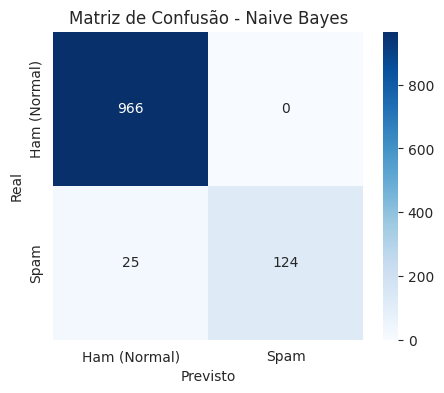

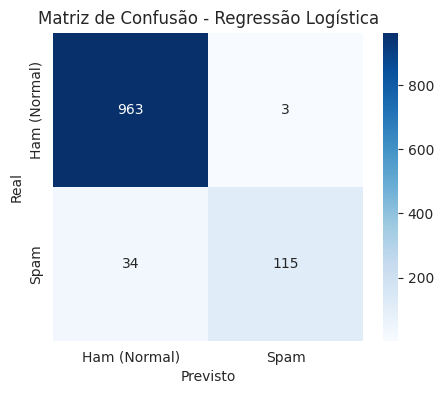

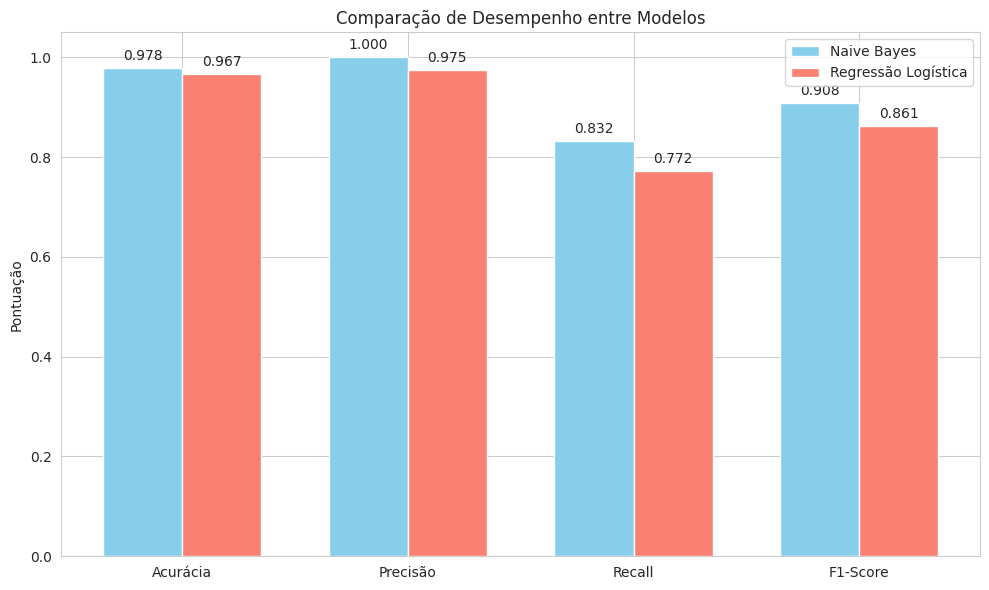


=== EXEMPLOS DE CLASSIFICAÇÃO CORRETA E ERRADA ===

Mensagem: lol grr mom taking forever prescription pharmacy like minutes away ugh...
  Real: Ham
  Naive Bayes: Ham
  Regressão:   Ham
----------------------------------------
Mensagem: best watch say cause get drunk motherfucker...
  Real: Ham
  Naive Bayes: Ham
  Regressão:   Ham
----------------------------------------
Mensagem: yes fine...
  Real: Ham
  Naive Bayes: Ham
  Regressão:   Ham
----------------------------------------
Mensagem: night ended another day morning come special way may smile like sunny rays leave...
  Real: Ham
  Naive Bayes: Ham
  Regressão:   Ham
----------------------------------------


In [16]:
# Função para plotar a matriz de confusão
def plotar_matriz_confusao(y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham (Normal)', 'Spam'],
                yticklabels=['Ham (Normal)', 'Spam'])
    plt.title(f'Matriz de Confusão - {titulo}')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()

# Plotar para os 2 modelos
plotar_matriz_confusao(y_test, y_pred_nb, "Naive Bayes")
plotar_matriz_confusao(y_test, y_pred_lr, "Regressão Logística")

# Gráfico de barras comparando as métricas
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
valores_nb = [metrics_nb[0], metrics_nb[1], metrics_nb[2], metrics_nb[3]]
valores_lr = [metrics_lr[0], metrics_lr[1], metrics_lr[2], metrics_lr[3]]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, valores_nb, width, label='Naive Bayes', color='skyblue')
bars2 = ax.bar(x + width/2, valores_lr, width, label='Regressão Logística', color='salmon')

ax.set_ylabel('Pontuação')
ax.set_title('Comparação de Desempenho entre Modelos')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.legend()
ax.set_ylim(0, 1.05)  # Deixa espaço em cima

# Adicionar os valores em cima das barras
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# --- Exemplos práticos (opcional, mas muito legal) ---
print("\n=== EXEMPLOS DE CLASSIFICAÇÃO CORRETA E ERRADA ===\n")
# Pega alguns índices do teste
indices = [10, 50, 100, 200]  # apenas exemplos
for idx in indices:
    if idx < len(X_test):
        texto_real = X_test.iloc[idx]
        label_real = y_test.iloc[idx]
        pred_nb = y_pred_nb[idx]
        pred_lr = y_pred_lr[idx]

        print(f"Mensagem: {texto_real[:80]}...")  # mostra só o início
        print(f"  Real: {'Spam' if label_real==1 else 'Ham'}")
        print(f"  Naive Bayes: {'Spam' if pred_nb==1 else 'Ham'}")
        print(f"  Regressão:   {'Spam' if pred_lr==1 else 'Ham'}")
        print("-" * 40)